In [1]:
import sys
import tensorflow as tf
print(tf.__version__)

D:\hk\soya_test\tfenv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


2.20.0


In [2]:
import os
import numpy as np

In [3]:
import cv2
print(cv2.__version__)

4.12.0


In [4]:
from PIL import Image

In [5]:
import torch
import torchvision

In [6]:
print(torch.__version__)
print(torchvision.__version__)

2.9.1+cpu
0.24.1+cpu


In [7]:
from torchvision import transforms

In [8]:
from tqdm import tqdm

In [9]:
data = []
labels = []

In [10]:
height = 64
width = 64
channels = 3

In [11]:
path1 = "D:/hk/1/hridayanath/processed/Corn___Cercospora_leaf_spot Gray_leaf_spot/"
path2 = "D:/hk/1/hridayanath/processed/Corn___Common_rust/"
path3 = "D:/hk/1/hridayanath/processed/Corn___healthy/"
path4 = "D:/hk/1/hridayanath/processed/Corn___Northern_Leaf_Blight/"

In [12]:
path = [path1, path2, path3, path4]

In [13]:
for i, p in enumerate(path):
    Class = os.listdir(p)
    for a in Class:
        if a.endswith('.jpg') or a.endswith('.png')or a.endswith('.JPG')or a.endswith('.jpeg'):  # Check if file is an image
            labels.append(i)
            try:
                image = cv2.imread(os.path.join(p, a))
                if image is not None:
                    image_from_array = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
                    size_image = image_from_array.resize((height, width))
                    data.append(np.array(size_image))
                else:
                    print(f"Error: Unable to read image at {os.path.join(p, a)}")
            except Exception as e:
                print(f"Error: {e}")

In [14]:
# Convert data and labels to numpy arrays
labels = np.array(labels)
data = np.array(data)

In [15]:
print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

Data shape: (4545, 64, 64, 3)
Labels shape: (4545,)


In [16]:
s = np.arange(data.shape[0])
np.random.seed(43)
np.random.shuffle(s)

In [17]:
from collections import Counter

# Count the occurrences of each label
label_counts = Counter(labels)

# Print the label counts
for label, count in label_counts.items():
    print(f"Label {label}: {count} samples")

Label 0: 1026 samples
Label 1: 1192 samples
Label 2: 1162 samples
Label 3: 1165 samples


In [18]:
# Define class names in the same order as 'path'
class_names = [
    "Corn___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn___Common_rust",
    "Corn___healthy",
    "Corn___Northern_Leaf_Blight"
]

In [19]:
# Count the occurrences of each label
label_counts = Counter(labels)

In [20]:
# Print the label counts with class names
for label, count in label_counts.items():
    print(f"{class_names[label]}: {count} samples")

Corn___Cercospora_leaf_spot Gray_leaf_spot: 1026 samples
Corn___Common_rust: 1192 samples
Corn___healthy: 1162 samples
Corn___Northern_Leaf_Blight: 1165 samples


In [21]:
from tensorflow.keras.applications import VGG16, ResNet101, MobileNetV2

In [22]:
# Load models without top classification layers (for feature extraction)
model_vgg16 = VGG16(weights='imagenet', include_top=False)
model_resnet101 = ResNet101(weights='imagenet', include_top=False)
model_mobilenetv2 = MobileNetV2(weights='imagenet', include_top=False)

C:\Users\Hp\AppData\Local\Temp\ipykernel_9560\1306144621.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model_mobilenetv2 = MobileNetV2(weights='imagenet', include_top=False)


In [23]:
features_vgg16 = model_vgg16.predict(data, batch_size=32)
features_resnet101 = model_resnet101.predict(data, batch_size=32)
features_mobilenetv2 = model_mobilenetv2.predict(data, batch_size=32)
extracted_features = []

143/143 ━━━━━━━━━━━━━━━━━━━━ 120s 830ms/step
143/143 ━━━━━━━━━━━━━━━━━━━━ 103s 688ms/step
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 107ms/step


In [24]:
print("VGG16:", features_vgg16.shape)
print("ResNet:", features_resnet101.shape)
print("MobileNet:", features_mobilenetv2.shape)

VGG16: (4545, 2, 2, 512)
ResNet: (4545, 2, 2, 2048)
MobileNet: (4545, 2, 2, 1280)


In [25]:
for f_v, f_r, f_m in zip(
        features_vgg16,
        features_resnet101,
        features_mobilenetv2):

    f_v = f_v.flatten()   # 2048
    f_r = f_r.flatten()   # 8192
    f_m = f_m.flatten()   # 5120

    fused = np.concatenate((f_v, f_r, f_m))
    extracted_features.append(fused)

extracted_features = np.array(extracted_features)

In [26]:
print(extracted_features.shape)

(4545, 15360)


In [27]:
# saving of feature array
np.save("D:/hk/maize_test/maize_fused_features.npy", extracted_features)
np.save("D:/hk/maize_test/maize_labels.npy", labels)

In [28]:
# reload from next time This saves you:
#CNN recomputation
#model downloads
#hours later
X = np.load("D:/hk/maize_test/maize_fused_features.npy")
y = np.load("D:/hk/maize_test/maize_labels.npy")

In [29]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical    
import time

In [30]:
print(labels.shape)

(4545,)


In [31]:
# 23/02/2026
labels = labels.astype(int)
labels_categorical = to_categorical(labels)
features = extracted_features

In [32]:
#23/02/2026 no concataion no duplication
print(features.shape)           # (4909, 15360)
print(labels.shape)             # (4909,)
print(labels_categorical.shape) # (4909, num_classes)

(4545, 15360)
(4545,)
(4545, 4)


In [33]:
def create_model(input_dim, num_classes):
    model = Sequential()
    model.add(Dense(512, input_shape=(input_dim,)))
    model.add(BatchNormalization())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(256))
    model.add(BatchNormalization())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(128))
    model.add(BatchNormalization())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [34]:
#23/02/2027 this to avoid overfitting
def create_model(input_dim, num_classes):
    model = Sequential()

    model.add(Dense(512, activation='relu', input_shape=(input_dim,)))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [35]:
temp_model = create_model(features.shape[1], labels_categorical.shape[1])
temp_model.summary()

D:\hk\soya_test\tfenv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │       7,864,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,297,860 (31.65 MB)

 Trainable params: 8,295,044 (31.64 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [36]:
print(features.shape)
print(labels_categorical.shape)

(4545, 15360)
(4545, 4)


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, cohen_kappa_score,
    matthews_corrcoef, mean_squared_error, auc
)
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
    
import time

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(features)
y = labels_categorical

In [39]:
from sklearn.metrics import classification_report

In [40]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

#original skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # changed to 4 on 20/02/2026
fold = 1

for train_idx, test_idx in skf.split(X, labels):
    print(f"\n=== Fold {fold} ===")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = labels_categorical[train_idx], labels_categorical[test_idx]
    y_train_labels = labels[train_idx]

    # Class weights (TRAIN ONLY)
    cw = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train_labels),
        y=y_train_labels
    )
    class_weight_dict = dict(enumerate(cw))

    # Model
    model = create_model(X.shape[1], y_train.shape[1])

    callbacks = [
        EarlyStopping(
            monitor='val_accuracy',
            patience=8,
            restore_best_weights=True
        )
    ]
# epoch changed to 10 from 100
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=10, 
        batch_size=32,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=1
    )

    # Predictions
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    class_names = [
    "Corn___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn___Common_rust",
    "Corn___healthy",
    "Corn___Northern_Leaf_Blight"
        ]

    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred,target_names=class_names))

    fold += 1



=== Fold 1 ===


D:\hk\soya_test\tfenv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 25s 163ms/step - accuracy: 0.6323 - loss: 0.9143 - val_accuracy: 0.8702 - val_loss: 0.3571
Epoch 2/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 158ms/step - accuracy: 0.8410 - loss: 0.4144 - val_accuracy: 0.9098 - val_loss: 0.2475
Epoch 3/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 160ms/step - accuracy: 0.8960 - loss: 0.2895 - val_accuracy: 0.9351 - val_loss: 0.1894
Epoch 4/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 157ms/step - accuracy: 0.9169 - loss: 0.2261 - val_accuracy: 0.9439 - val_loss: 0.1555
Epoch 5/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 158ms/step - accuracy: 0.9387 - loss: 0.1837 - val_accuracy: 0.9593 - val_loss: 0.1351
Epoch 6/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 156ms/step - accuracy: 0.9494 - loss: 0.1438 - val_accuracy: 0.9604 - val_loss: 0.1180
Epoch 7/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 155ms/step - accuracy: 0.9598 - loss: 0.1201 - val_accuracy: 0.9659 - val_loss: 0.1186
Epoch 8/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 157ms/step - accuracy: 0.9664 - loss: 0

D:\hk\soya_test\tfenv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 25s 165ms/step - accuracy: 0.6064 - loss: 1.0091 - val_accuracy: 0.8966 - val_loss: 0.3576
Epoch 2/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 158ms/step - accuracy: 0.8182 - loss: 0.4842 - val_accuracy: 0.9351 - val_loss: 0.2148
Epoch 3/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 158ms/step - accuracy: 0.8746 - loss: 0.3377 - val_accuracy: 0.9417 - val_loss: 0.1685
Epoch 4/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 19s 162ms/step - accuracy: 0.9081 - loss: 0.2578 - val_accuracy: 0.9494 - val_loss: 0.1359
Epoch 5/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 20s 159ms/step - accuracy: 0.9365 - loss: 0.1871 - val_accuracy: 0.9527 - val_loss: 0.1246
Epoch 6/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 158ms/step - accuracy: 0.9502 - loss: 0.1516 - val_accuracy: 0.9692 - val_loss: 0.0946
Epoch 7/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 19s 163ms/step - accuracy: 0.9596 - loss: 0.1271 - val_accuracy: 0.9670 - val_loss: 0.0943
Epoch 8/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 157ms/step - accuracy: 0.9697 - loss: 0

...

Epoch 1/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 22s 157ms/step - accuracy: 0.6488 - loss: 0.8871 - val_accuracy: 0.8746 - val_loss: 0.3175
Epoch 2/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 155ms/step - accuracy: 0.8292 - loss: 0.4305 - val_accuracy: 0.9032 - val_loss: 0.2203
Epoch 3/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 21s 155ms/step - accuracy: 0.8765 - loss: 0.3110 - val_accuracy: 0.9274 - val_loss: 0.1727
Epoch 4/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 155ms/step - accuracy: 0.9161 - loss: 0.2385 - val_accuracy: 0.9483 - val_loss: 0.1336
Epoch 5/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 155ms/step - accuracy: 0.9373 - loss: 0.1906 - val_accuracy: 0.9560 - val_loss: 0.1065
Epoch 6/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 156ms/step - accuracy: 0.9455 - loss: 0.1531 - val_accuracy: 0.9593 - val_loss: 0.0989
Epoch 7/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 156ms/step - accuracy: 0.9571 - loss: 0.1215 - val_accuracy: 0.9692 - val_loss: 0.0844
Epoch 8/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 159ms/step - accuracy: 0.9711 - loss: 0

D:\hk\soya_test\tfenv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 22s 158ms/step - accuracy: 0.6320 - loss: 0.9536 - val_accuracy: 0.8779 - val_loss: 0.3264
Epoch 2/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 154ms/step - accuracy: 0.8303 - loss: 0.4505 - val_accuracy: 0.9098 - val_loss: 0.2175
Epoch 3/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 155ms/step - accuracy: 0.8817 - loss: 0.3246 - val_accuracy: 0.9417 - val_loss: 0.1563
Epoch 4/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 17s 153ms/step - accuracy: 0.9101 - loss: 0.2566 - val_accuracy: 0.9395 - val_loss: 0.1319
Epoch 5/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 155ms/step - accuracy: 0.9384 - loss: 0.1885 - val_accuracy: 0.9527 - val_loss: 0.1115
Epoch 6/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 154ms/step - accuracy: 0.9455 - loss: 0.1528 - val_accuracy: 0.9659 - val_loss: 0.1025
Epoch 7/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 17s 153ms/step - accuracy: 0.9587 - loss: 0.1248 - val_accuracy: 0.9692 - val_loss: 0.0885
Epoch 8/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 154ms/step - accuracy: 0.9684 - loss: 0

D:\hk\soya_test\tfenv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 22s 159ms/step - accuracy: 0.6045 - loss: 0.9653 - val_accuracy: 0.8724 - val_loss: 0.3445
Epoch 2/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 155ms/step - accuracy: 0.8237 - loss: 0.4647 - val_accuracy: 0.9153 - val_loss: 0.2265
Epoch 3/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 154ms/step - accuracy: 0.8721 - loss: 0.3324 - val_accuracy: 0.9285 - val_loss: 0.1812
Epoch 4/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 154ms/step - accuracy: 0.9147 - loss: 0.2397 - val_accuracy: 0.9439 - val_loss: 0.1481
Epoch 5/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 154ms/step - accuracy: 0.9345 - loss: 0.1998 - val_accuracy: 0.9505 - val_loss: 0.1389
Epoch 6/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 156ms/step - accuracy: 0.9469 - loss: 0.1521 - val_accuracy: 0.9582 - val_loss: 0.1277
Epoch 7/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 18s 154ms/step - accuracy: 0.9634 - loss: 0.1139 - val_accuracy: 0.9604 - val_loss: 0.1186
Epoch 8/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 17s 153ms/step - accuracy: 0.9722 - loss: 0

In [41]:
from tensorflow.keras.models import save_model
import joblib

# Save final model from the last fold
model.save("D:/hk/maize_test/maize_disease_model1.h5")

In [42]:
def preprocess_image(img_path, height=64, width=64):
    import cv2
    from PIL import Image
    
    # Read & resize
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = Image.fromarray(image).resize((height, width))
    image = np.array(image)

    # Expand batch dimension
    return np.expand_dims(image, axis=0)   # shape (1, h, w, c)

In [43]:
# 23/02/2026
from tensorflow.keras.applications import VGG16, ResNet101, MobileNetV2
import numpy as np

# Load same feature extractors used before
model_vgg16 = VGG16(weights="imagenet", include_top=False)
model_resnet101 = ResNet101(weights="imagenet", include_top=False)
model_mobilenetv2 = MobileNetV2(weights="imagenet", include_top=False)

# Freeze models (important for inference)
model_vgg16.trainable = False
model_resnet101.trainable = False
model_mobilenetv2.trainable = False


def extract_fusion_features(image):
    # Features from each backbone
    f_r = model_vgg16.predict(image, verbose=0)
    f_d = model_resnet101.predict(image, verbose=0)
    f_e = model_mobilenetv2.predict(image, verbose=0)

    # Flatten
    f_r = f_r.reshape(-1)
    f_d = f_d.reshape(-1)
    f_e = f_e.reshape(-1)

    # Fusion (concatenate)
    fused = np.concatenate([f_r, f_d, f_e], axis=0)

    # IMPORTANT: return fused features (same as training)
    return fused.reshape(1, -1)   # (1, 15360)

C:\Users\Hp\AppData\Local\Temp\ipykernel_9560\3885398823.py:8: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model_mobilenetv2 = MobileNetV2(weights="imagenet", include_top=False)


In [44]:
test = np.zeros((1,64,64,3))
print(extract_fusion_features(test).shape)

(1, 15360)


In [45]:
test = np.zeros((1,64,64,3))
features_test = extract_fusion_features(test)

print("Extracted shape:", features_test.shape)
print("Model expects :", model.input_shape)

Extracted shape: (1, 15360)
Model expects : (None, 15360)


In [46]:
 class_names = [
    "Corn___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn___Common_rust",
    "Corn___healthy",
    "Corn___Northern_Leaf_Blight"
        ]

In [47]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# === Load your trained model ===
model_path = "D:/hk/maize_test/maize_disease_model1.h5"
model = load_model(model_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


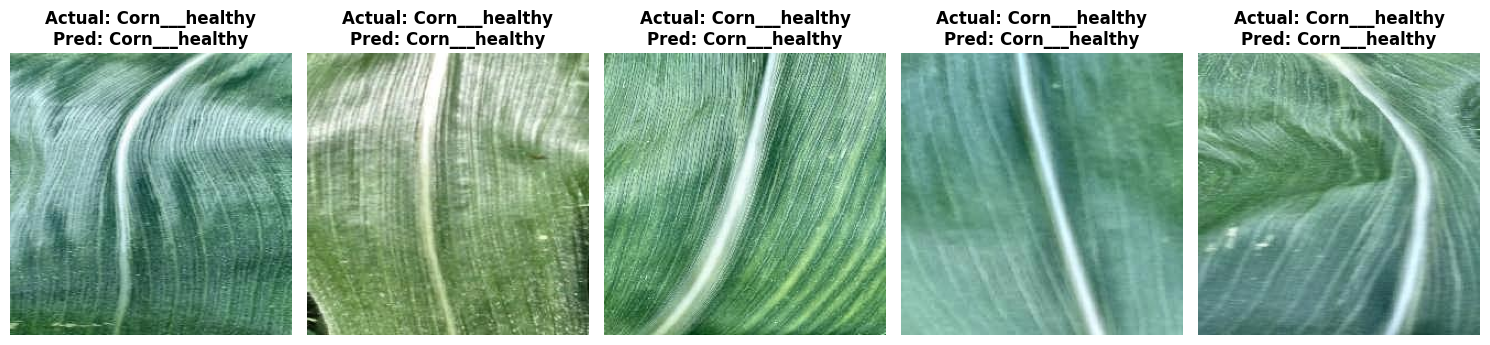

In [48]:
# Path to images
folder = "D:/hk/1/hridayanath/processed/Corn___healthy/"
images = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(('.jpg', '.png'))][:5]

# Get actual label index from folder name
folder_name = os.path.basename(os.path.normpath(folder))
actual_label = class_names.index(folder_name)   # assumes folder_name is in class_names

plt.figure(figsize=(15, 8))
for i, img_path in enumerate(images):
    plt.subplot(1, 5, i+1)
    
    # preprocess + feature extraction
    img_array = preprocess_image(img_path)
    fusion_features = extract_fusion_features(img_array)
    pred_probs = model.predict(fusion_features)
    pred_label = np.argmax(pred_probs)

    # read image for plotting
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Actual: {class_names[actual_label]}\nPred: {class_names[pred_label]}",
        fontsize=12, weight='bold'
    )

plt.tight_layout()
plt.show()

In [49]:
print(class_names[pred_label])

Corn___healthy


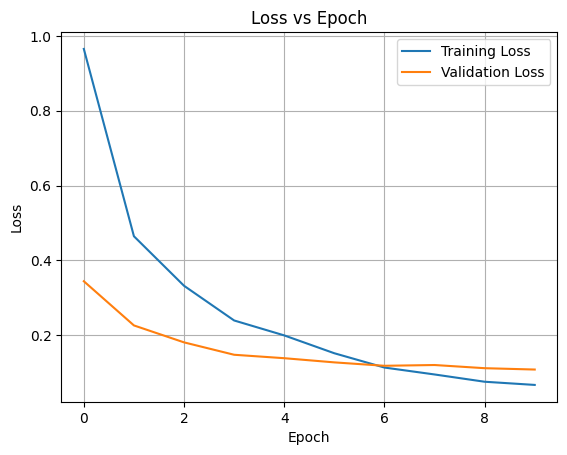

In [50]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

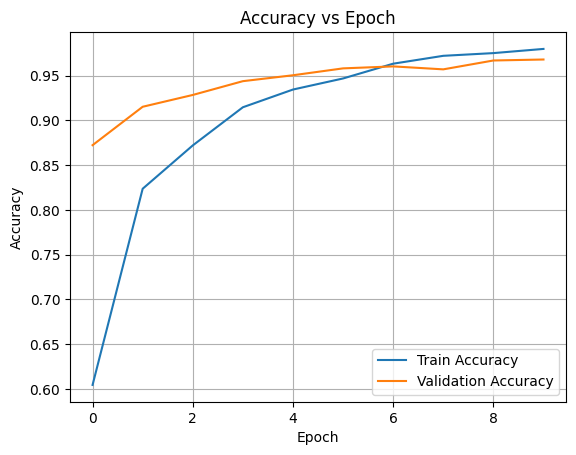

In [51]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.grid(True)
plt.show()